In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load the data
df = pd.read_csv('House Price India.csv')
print("shape of data :",df.shape)
print(df.head())

shape of data : (14619, 23)
           id   Date  number of bedrooms  number of bathrooms  living area  \
0  6762810635  42491                   4                 2.50         2920   
1  6762810998  42491                   5                 2.75         2910   
2  6762812605  42491                   4                 2.50         3310   
3  6762812919  42491                   3                 2.00         2710   
4  6762813105  42491                   3                 2.50         2600   

   lot area  number of floors  waterfront present  number of views  \
0      4000               1.5                   0                0   
1      9480               1.5                   0                0   
2     42998               2.0                   0                0   
3      4500               1.5                   0                0   
4      4750               1.0                   0                0   

   condition of the house  ...  Built Year  Renovation Year  Postal Code  \
0     

In [ ]:
#describing the data
print(df.describe())

                 id          Date  number of bedrooms  number of bathrooms  \
count  1.461900e+04  14619.000000        14619.000000         14619.000000   
mean   6.762821e+09  42604.546412            3.379233             2.129557   
std    6.237162e+03     67.343747            0.938655             0.769955   
min    6.762810e+09  42491.000000            1.000000             0.500000   
25%    6.762815e+09  42546.000000            3.000000             1.750000   
50%    6.762821e+09  42600.000000            3.000000             2.250000   
75%    6.762826e+09  42662.000000            4.000000             2.500000   
max    6.762832e+09  42734.000000           33.000000             8.000000   

        living area      lot area  number of floors  waterfront present  \
count  14619.000000  1.461900e+04      14619.000000        14619.000000   
mean    2098.156851  1.509369e+04          1.502326            0.007661   
std      928.218740  3.792089e+04          0.540241            0.087196 

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

In [ ]:
#3. Identify target and feature types
target = "Price"
# Numerical and categorical columns
print("\n📌 Column names:")
print(df.columns.tolist())



📌 Column names:


NameError: name 'df' is not defined

In [ ]:
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print("\n📌 Numerical columns:")
print(numerical_columns)
print("\n📌 Categorical columns:")
print(categorical_columns)


📌 Numerical columns:
['id', 'Date', 'number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'waterfront present', 'number of views', 'condition of the house', 'grade of the house', 'Area of the house(excluding basement)', 'Area of the basement', 'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude', 'Longitude', 'living_area_renov', 'lot_area_renov', 'Number of schools nearby', 'Distance from the airport', 'Price']

📌 Categorical columns:
[]


In [ ]:
#check for any missing values
print(f"\nmissing values")
print(df.isnull().sum())


missing values
id                                       0
Date                                     0
number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Postal Code                              0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Number of schools nearby                 0
Distance from the airport                0
Price                                 

In [ ]:
#duplicated values and their sum
print(f"\nduplicated values")
print(df.duplicated().sum())


duplicated values
0


In [ ]:
#check unique values
print(df['Postal Code'].unique())
print(df['id'].unique())

[122004 122005 122006 122007 122008 122009 122010 122011 122012 122013
 122014 122015 122016 122017 122018 122019 122020 122021 122022 122023
 122024 122025 122026 122027 122028 122029 122030 122031 122032 122033
 122034 122035 122036 122037 122038 122039 122040 122041 122042 122043
 122044 122045 122046 122047 122048 122049 122003 122050 122051 122052
 122053 122054 122055 122056 122057 122058 122059 122060 122061 122062
 122063 122064 122065 122066 122067 122068 122069 122070 122071 122072]
[6762810635 6762810998 6762812605 ... 6762830618 6762830709 6762831463]


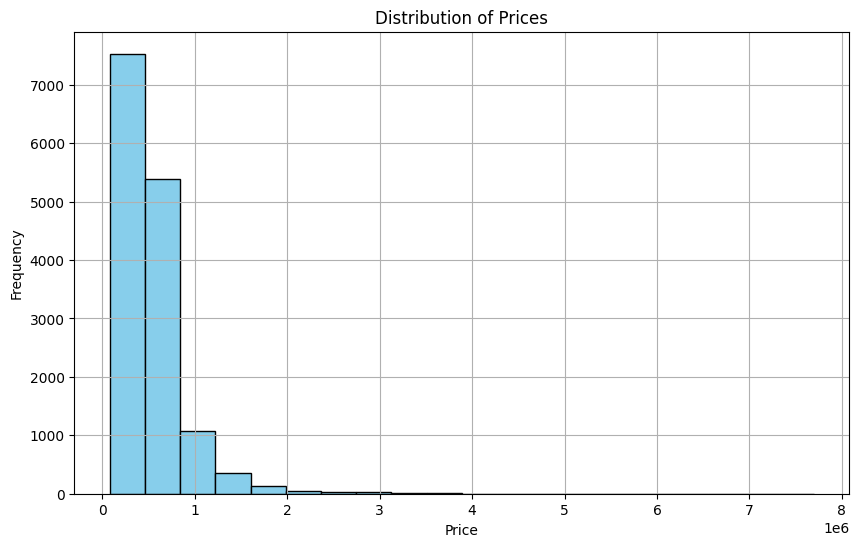

In [ ]:

#visualize prize distribution
#  Quick look at target variable (Price)
plt.figure(figsize=(10, 6))
plt.hist(df['Price'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Prices')
plt.grid(True)


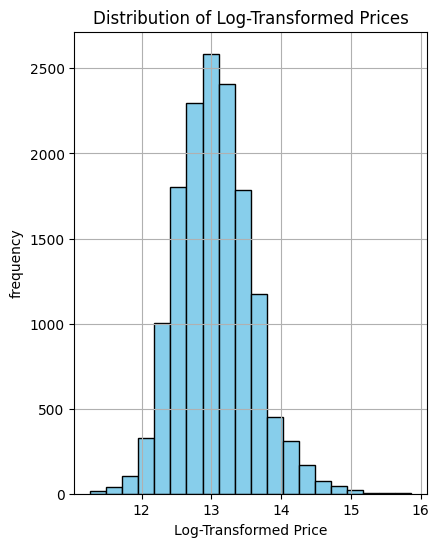

In [ ]:
# Optional: log-transform view if skewed
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.hist(np.log(df["Price"]), bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Log-Transformed Price')
plt.ylabel("frequency")
plt.title('Distribution of Log-Transformed Prices')
plt.grid(True)


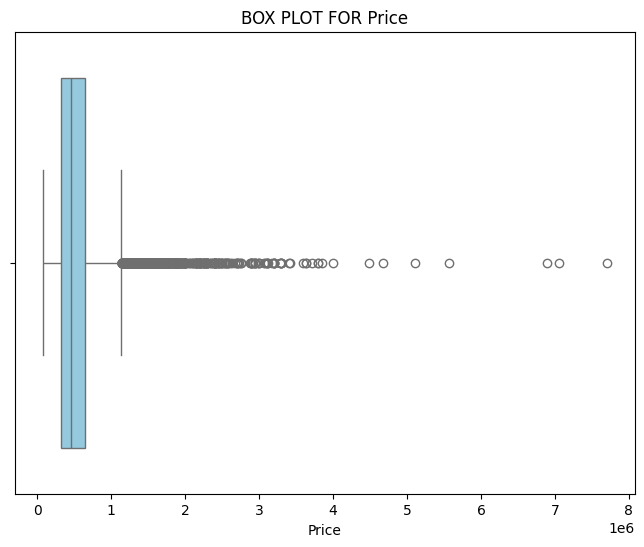

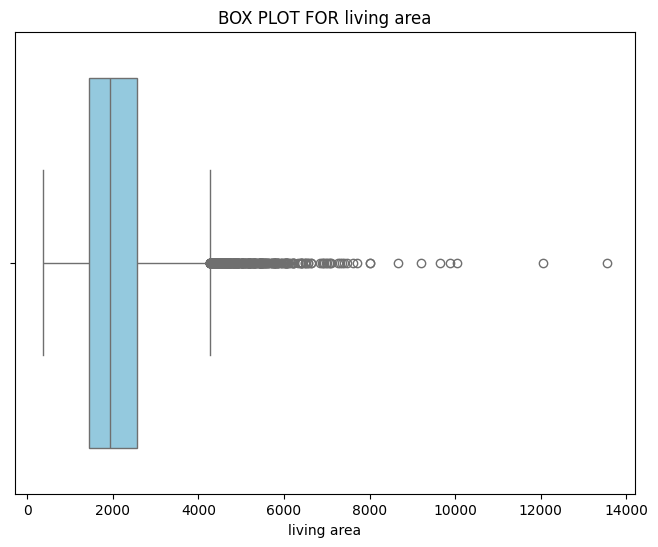

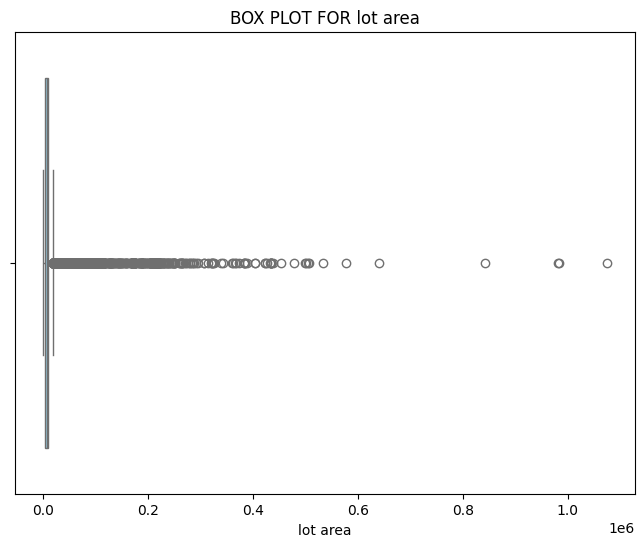

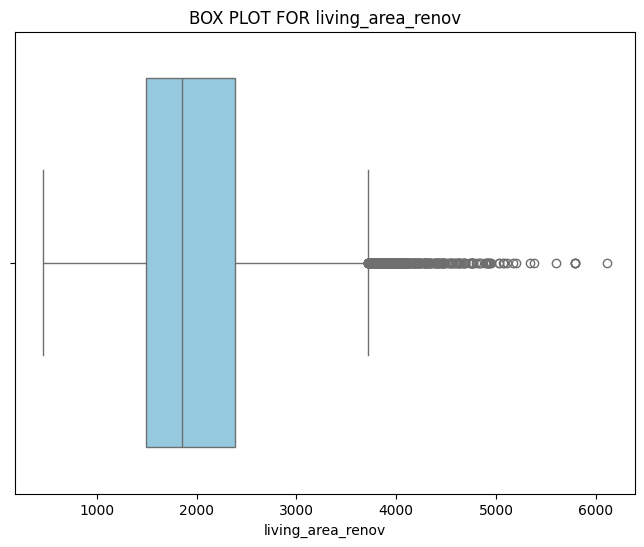

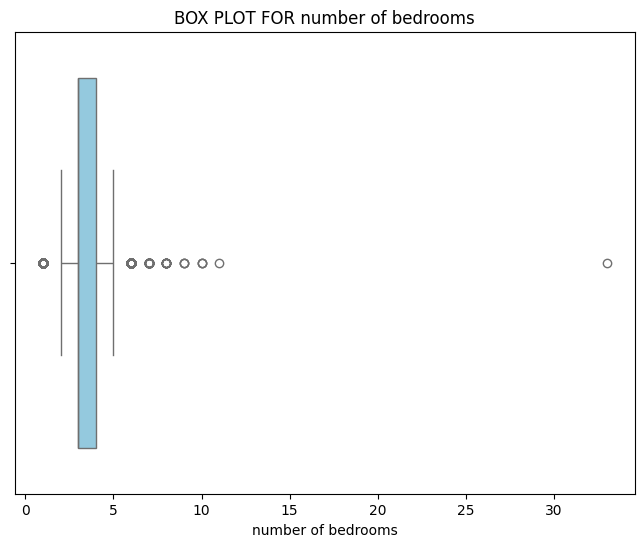

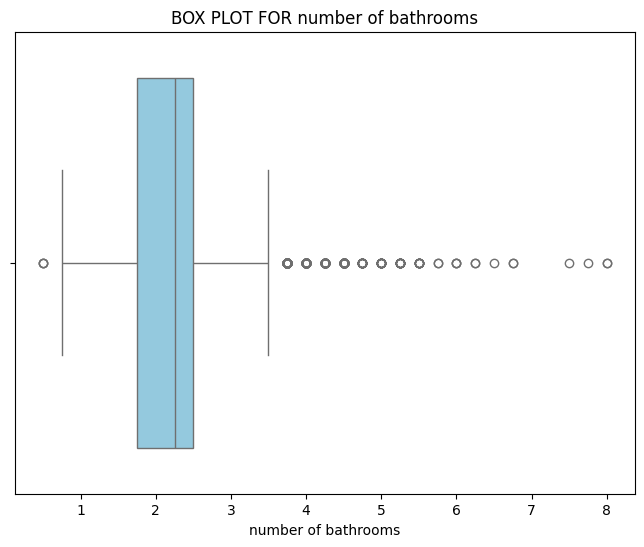

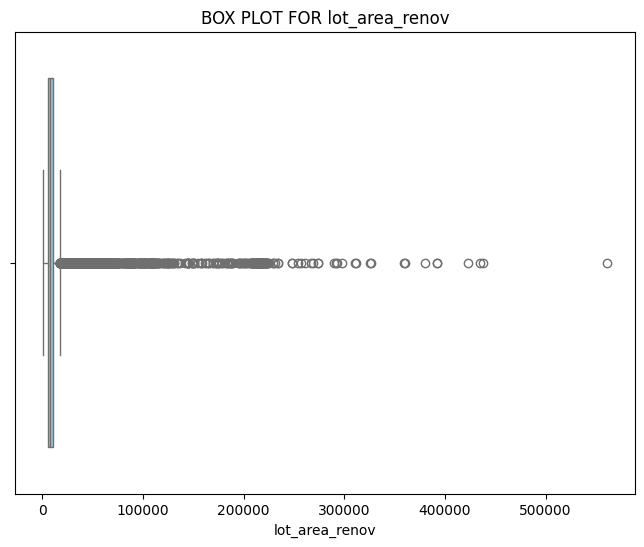

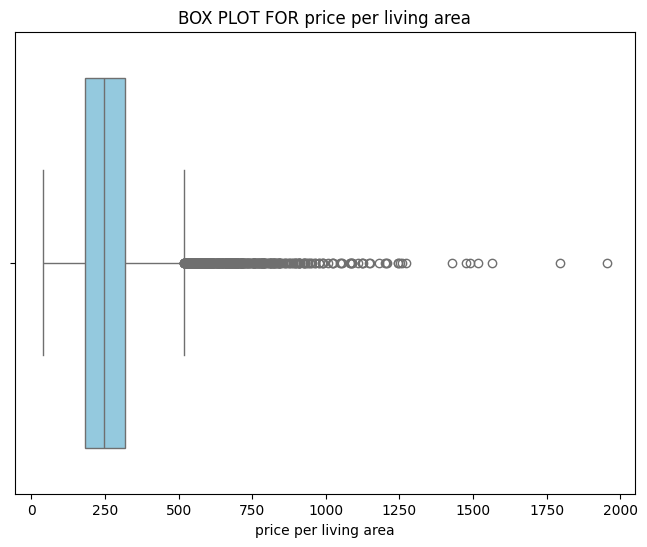

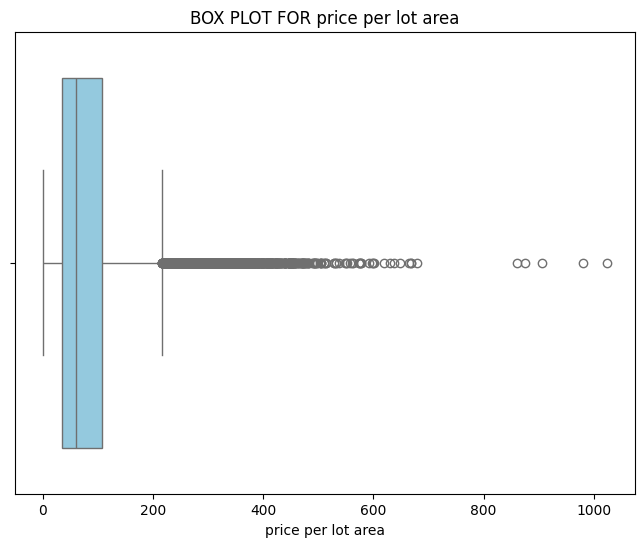

In [ ]:
#to identify outliers using boxplot in key numerical columns
df["price per living area"] = df["Price"] / df["living_area_renov"]
df["price per lot area"] = df["Price"] / df["lot_area_renov"]
key_columns = ['Price', 'living area','lot area','living_area_renov', 'number of bedrooms','number of bathrooms','lot_area_renov',"price per living area","price per lot area"]
for col in key_columns:
  plt.figure(figsize=(8, 6))
  sns.boxplot(x=df[col].dropna(), color='skyblue')


  plt.title("BOX PLOT FOR "+col)
  plt.show()




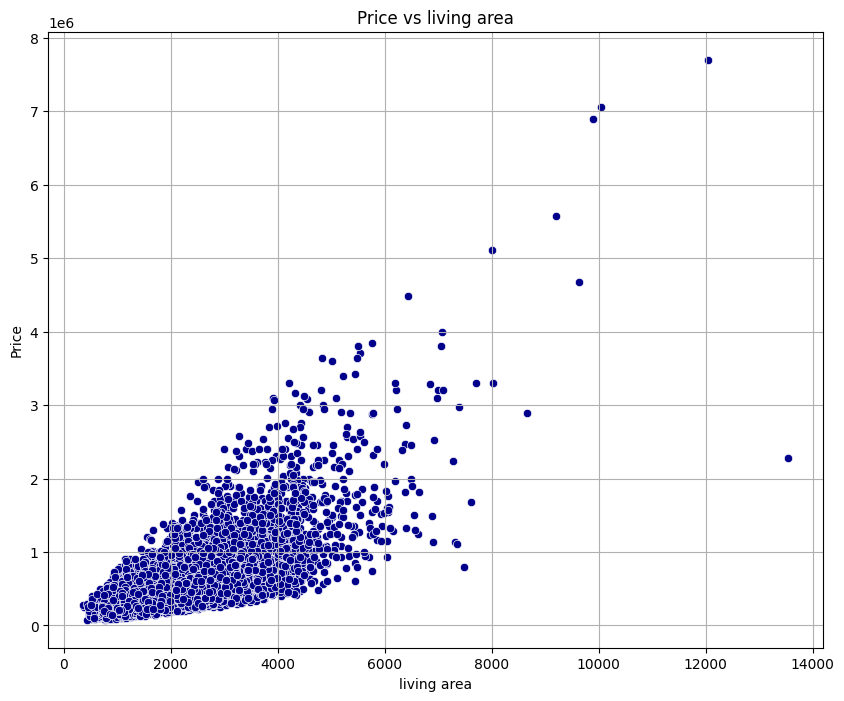

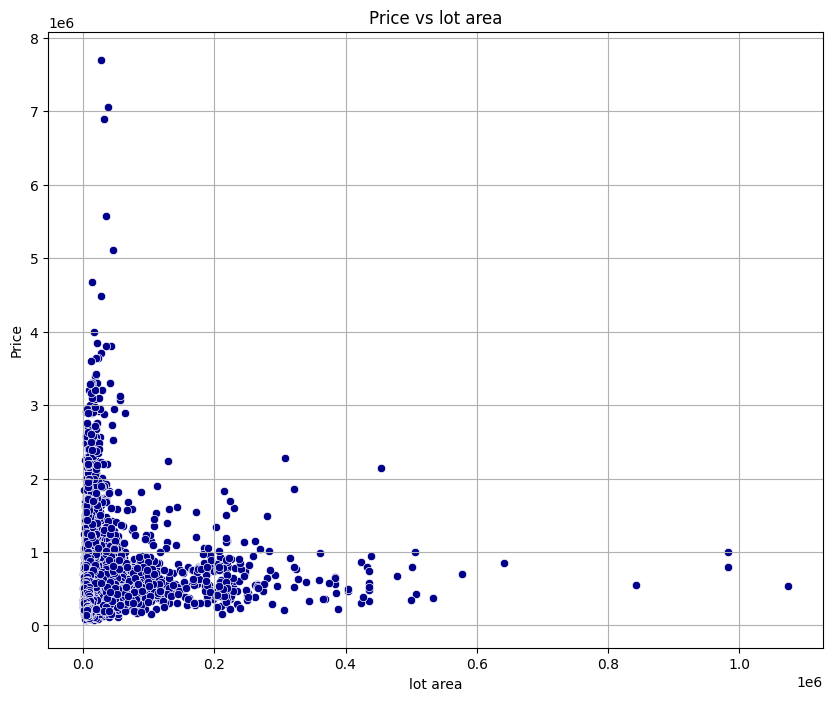

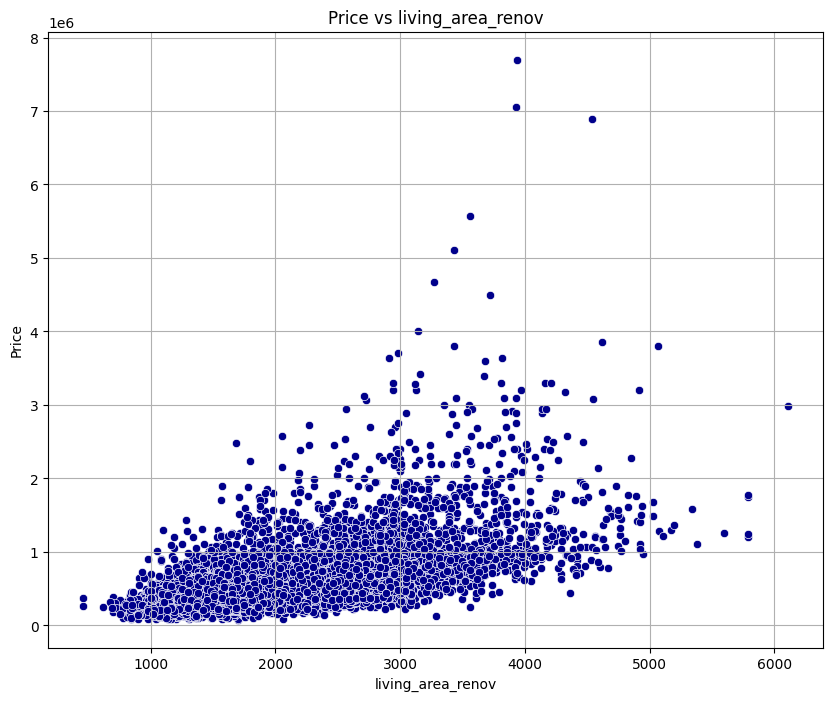

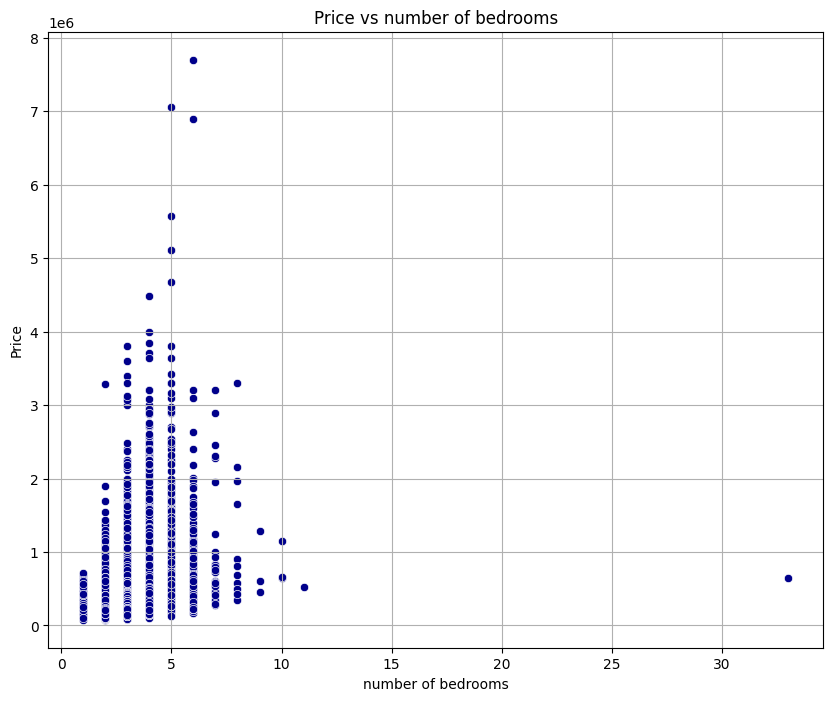

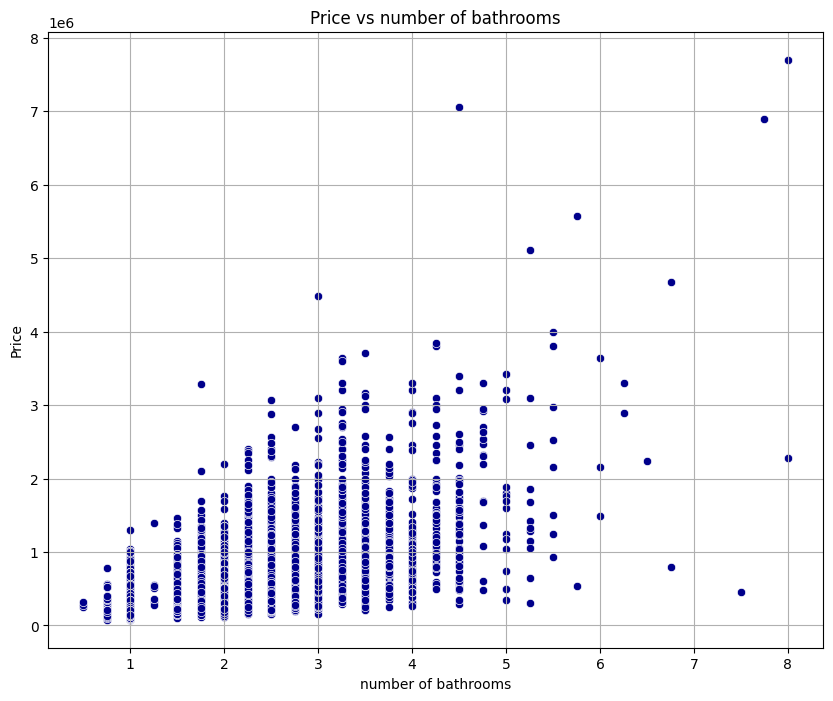

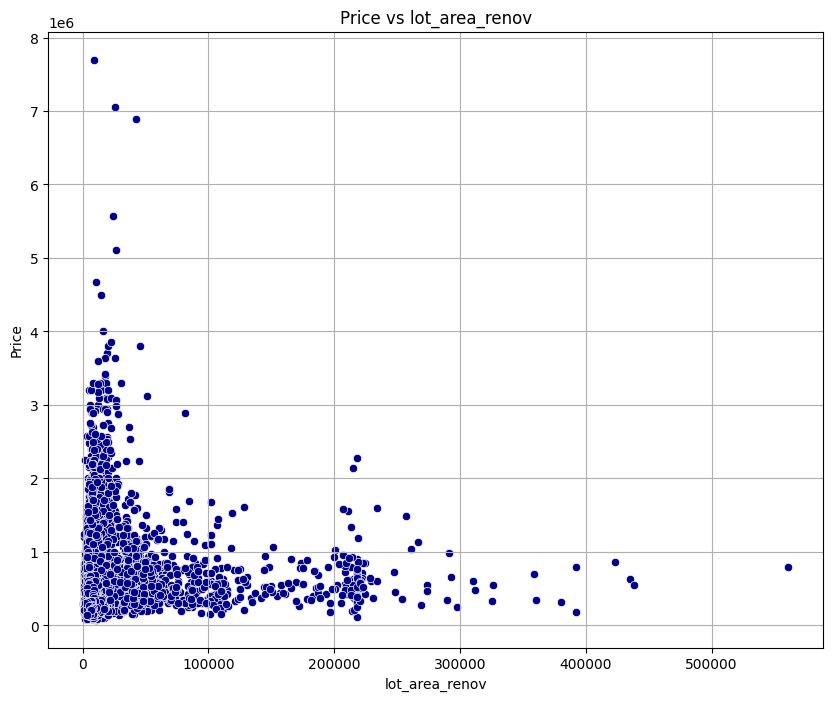

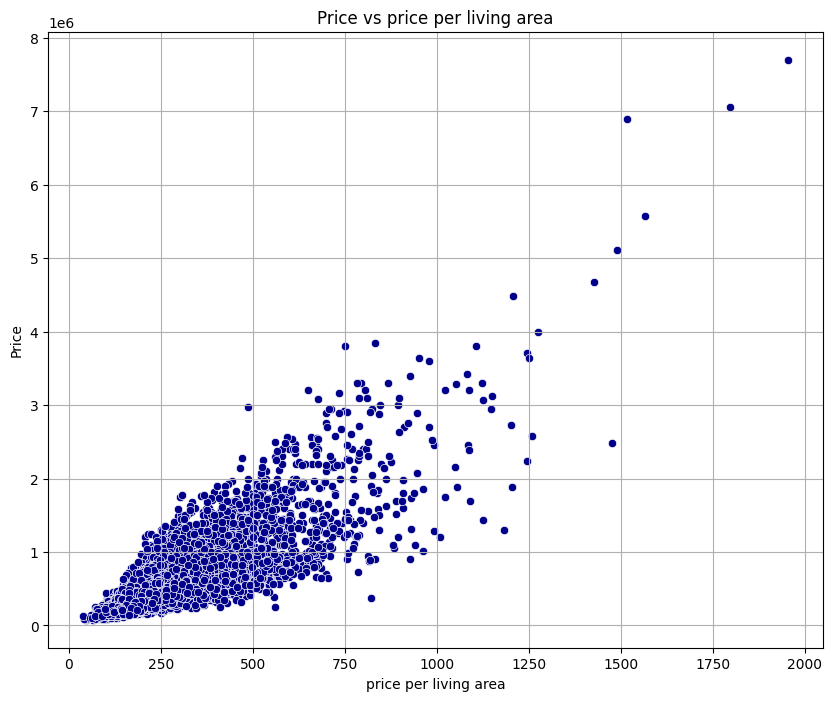

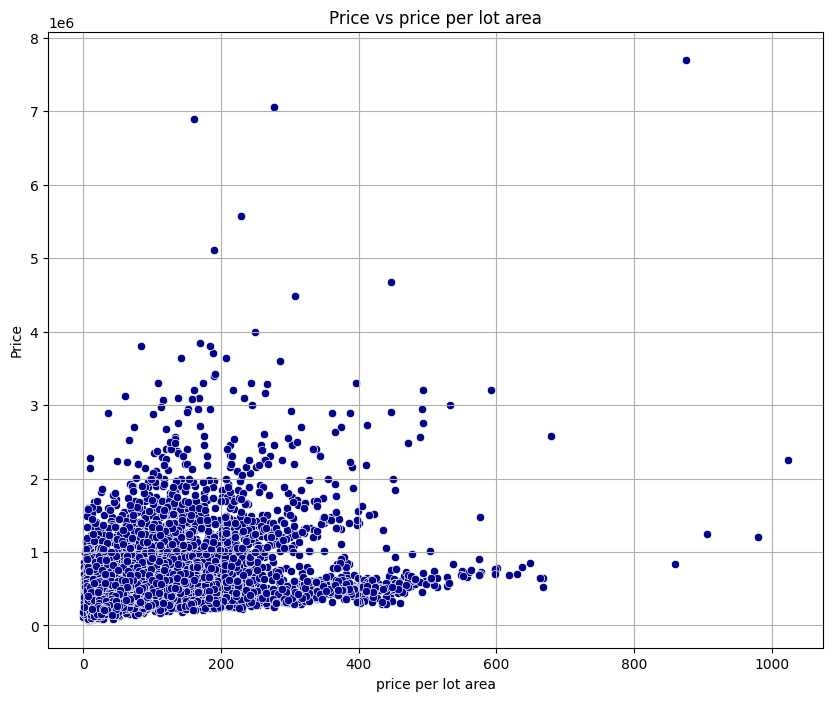

In [ ]:
#price vs key_columns relation
for col in key_columns[1:]:
  plt.figure(figsize=(10,8))
  sns.scatterplot(x=df[col], y=df['Price'], color='darkblue')
  plt.xlabel(col)
  plt.ylabel('Price')
  plt.title(f'Price vs {col}')
  plt.grid(True)
  plt.show()

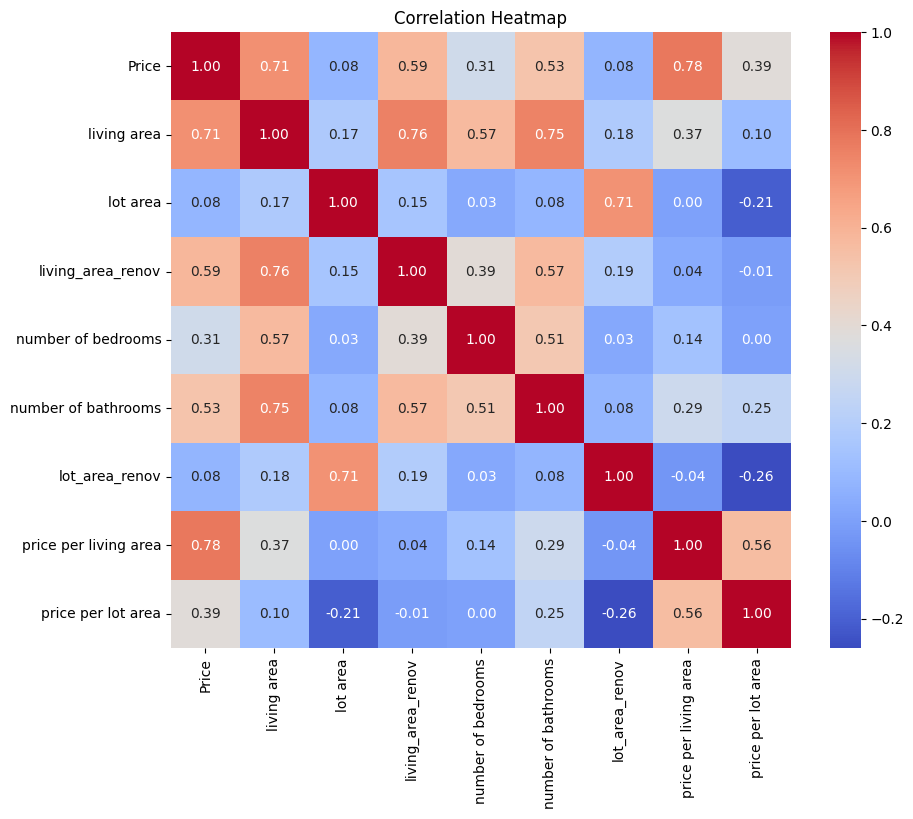

In [ ]:
#correlation of key_columns with target=Price and correlation heatmap
correlation_matrix = df[key_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


#**PRE PROCESSING STEPS**

In [ ]:
#Pre processing : import
# 0. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



In [ ]:
# 1. Load the dataset
# ---------------------------------------------------------
file_path = "House Price India.csv"   # change if needed
df = pd.read_csv(file_path)

print("✅ Data loaded. Shape:", df.shape)
print(df.head())

✅ Data loaded. Shape: (14619, 23)
           id   Date  number of bedrooms  number of bathrooms  living area  \
0  6762810635  42491                   4                 2.50         2920   
1  6762810998  42491                   5                 2.75         2910   
2  6762812605  42491                   4                 2.50         3310   
3  6762812919  42491                   3                 2.00         2710   
4  6762813105  42491                   3                 2.50         2600   

   lot area  number of floors  waterfront present  number of views  \
0      4000               1.5                   0                0   
1      9480               1.5                   0                0   
2     42998               2.0                   0                0   
3      4500               1.5                   0                0   
4      4750               1.0                   0                0   

   condition of the house  ...  Built Year  Renovation Year  Postal Code  \


In [ ]:
# Drop columns that are not useful for prediction
# 'id' is just an identifier → not useful for learning patterns
# 'Date' here is an Excel-style numeric date; for now we drop it to keep things simple.
# (You can later convert it to real date and extract year/month if you want.)
df = df.drop(columns=['id','Date'], errors='ignore')
df.columns.tolist()

['number of bedrooms',
 'number of bathrooms',
 'living area',
 'lot area',
 'number of floors',
 'waterfront present',
 'number of views',
 'condition of the house',
 'grade of the house',
 'Area of the house(excluding basement)',
 'Area of the basement',
 'Built Year',
 'Renovation Year',
 'Postal Code',
 'Lattitude',
 'Longitude',
 'living_area_renov',
 'lot_area_renov',
 'Number of schools nearby',
 'Distance from the airport',
 'Price']

In [ ]:
# 3. Handle special columns (dataset-specific logic)
# In this dataset, 'Renovation Year' = 0 means "never renovated".
# Two good ways to handle this:
# (A) Replace 0 with NaN so the model learns "missing = not renovated"
# (B) Create a new binary feature "is_renovated" and keep the year

df['Renovation year'] = df['Renovation Year'].replace(0, np.nan)
df['is_renovated'] = (df['Renovation Year'] != 0).astype(int)
df.columns.tolist()
df['is_renovated'].head()

,is_renovated
0,0
1,0
2,0
3,0
4,0


In [ ]:
#Dropping and Handling missing values
df.columns.tolist()
df.isnull().sum()


,0
number of bedrooms,0
number of bathrooms,0
living area,0
lot area,0
number of floors,0
waterfront present,0
number of views,0
condition of the house,0
grade of the house,0
Area of the house(excluding basement),0


<Axes: >

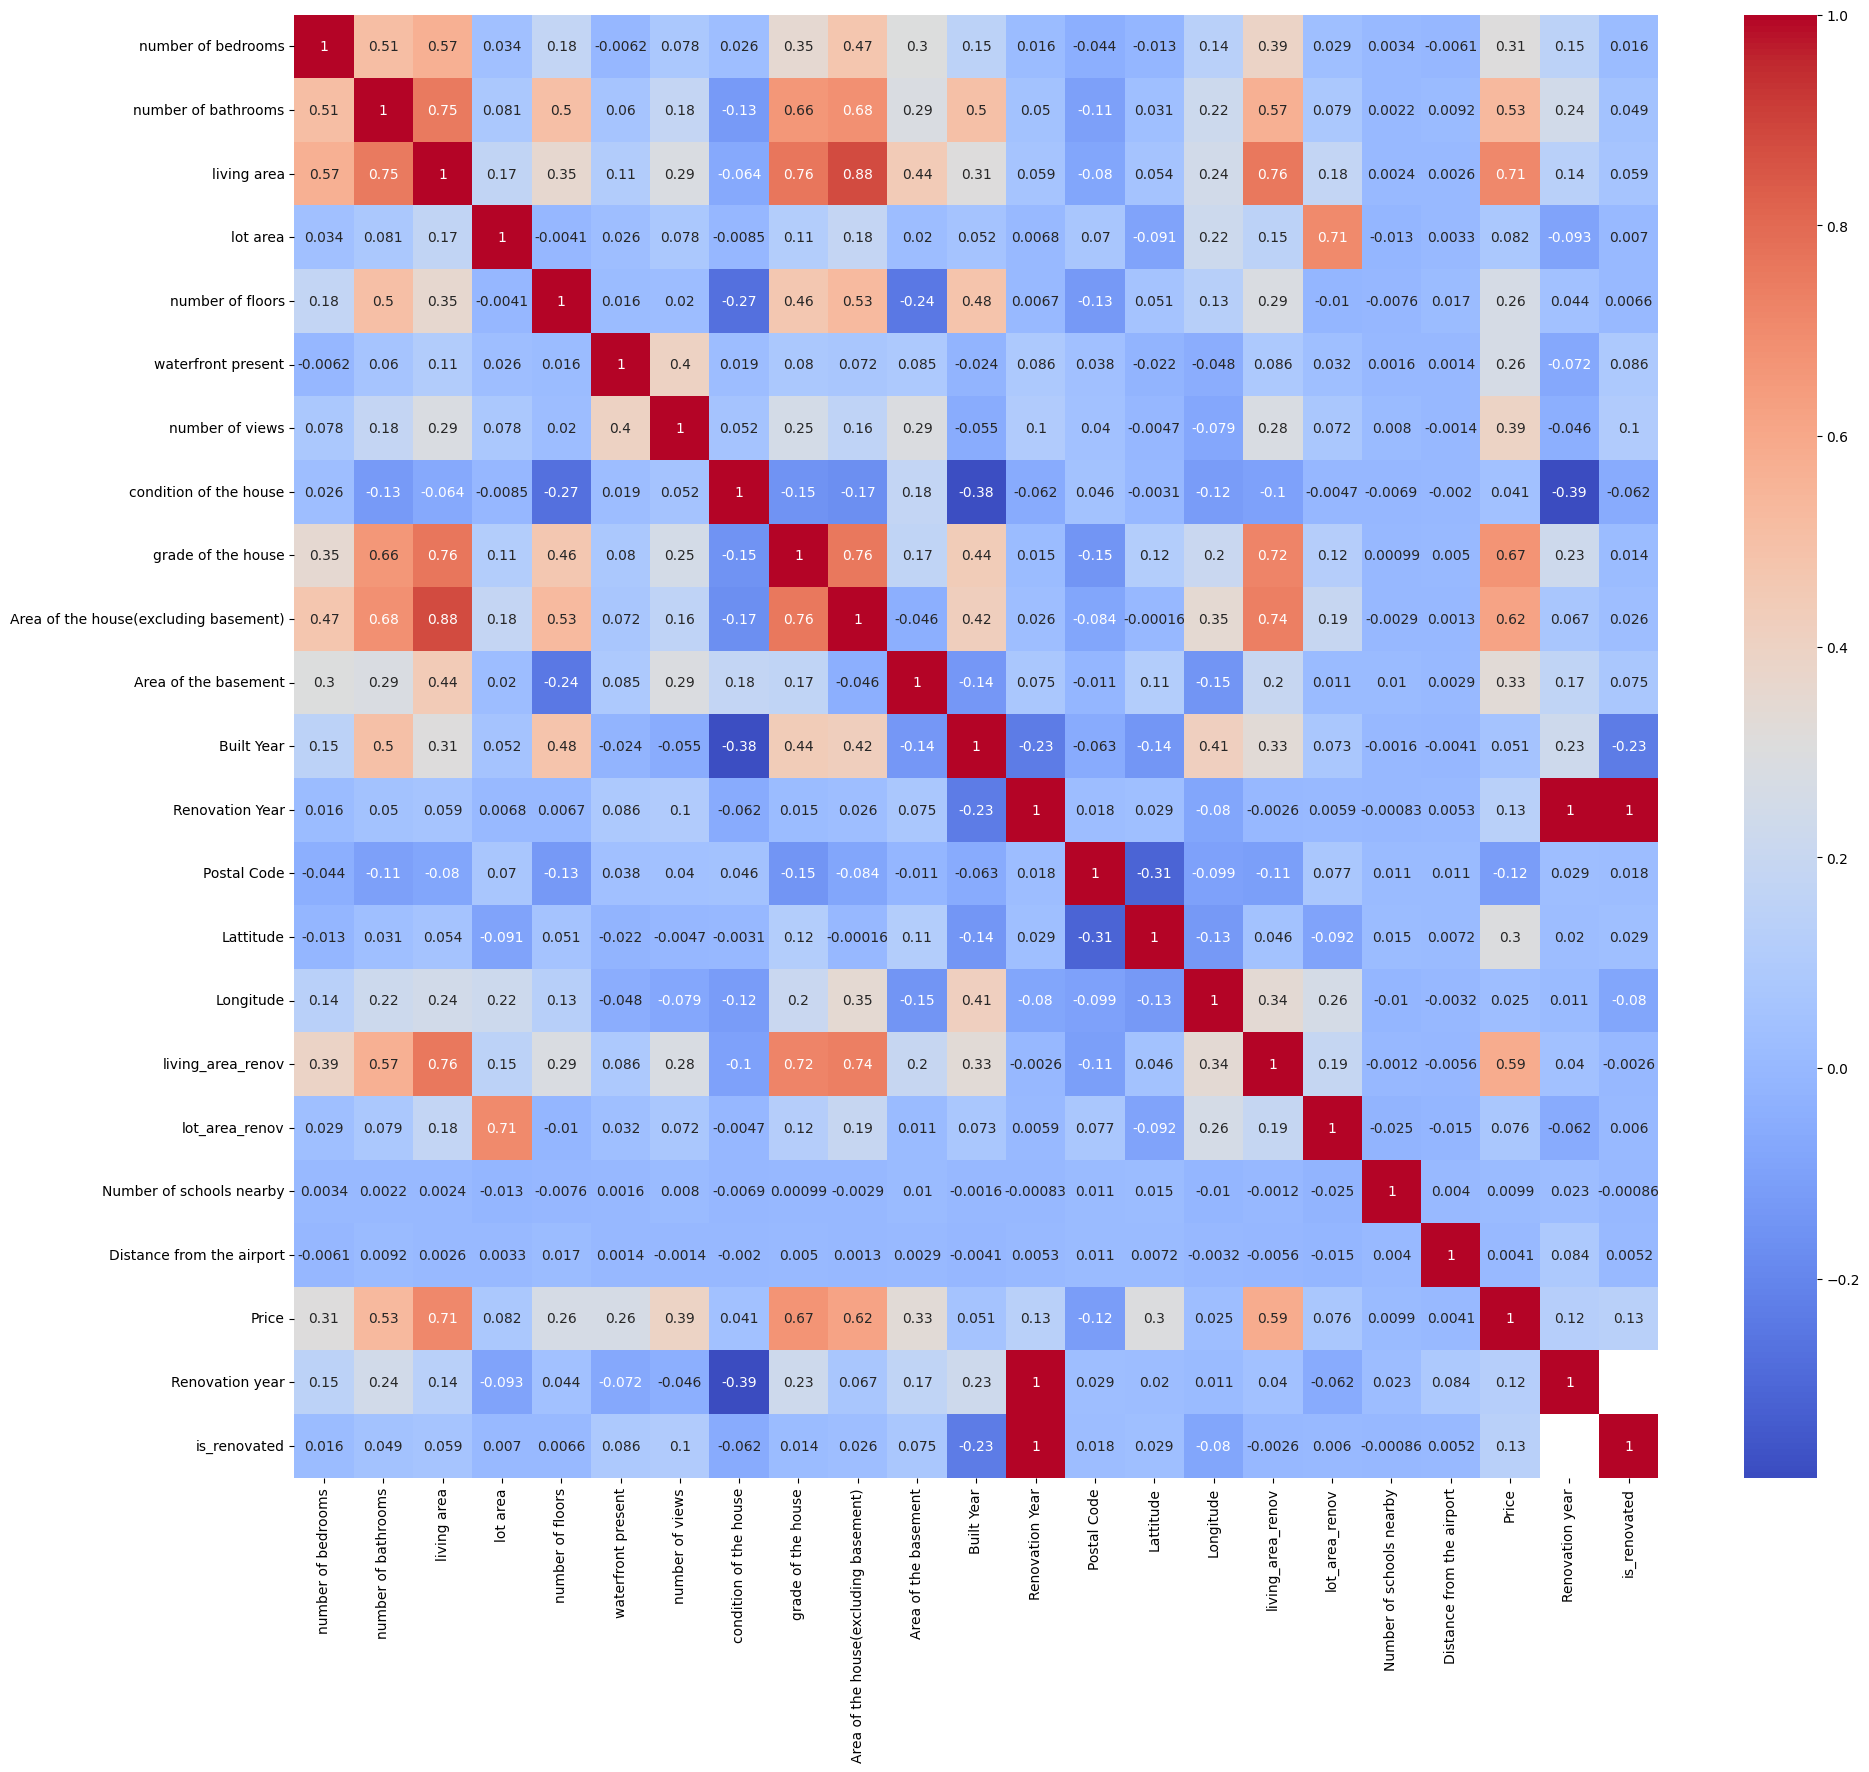

In [ ]:
#we will plot heatmap for all features to understand correlation better
plt.figure(figsize=(22, 19))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [ ]:
print(numerical_columns)
#since no categorical_columns
X = df.drop(columns=['Price','id','Date','Postal Code','Distance from the airport', 'Renovation year'], errors='ignore')
y = df['Price']
print(X.shape ,"Features shape")
print(y.shape ,"Target shape")

['id', 'Date', 'number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'waterfront present', 'number of views', 'condition of the house', 'grade of the house', 'Area of the house(excluding basement)', 'Area of the basement', 'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude', 'Longitude', 'living_area_renov', 'lot_area_renov', 'Number of schools nearby', 'Distance from the airport', 'Price']
(14619, 19) Features shape
(14619,) Target shape


In [ ]:
# 5. Identify numeric and categorical features
# ---------------------------------------------------------
# In this dataset, all columns are numeric already,
# but some are "categorical-like" (e.g., condition, grade, waterfront as 0/1).
# For now, we’ll treat everything as numeric for scaling. That’s totally fine.
#let numerical features excluding price be numeric
numeric = X.columns.tolist()
# If you ever had real string columns, you’d separate:
# categorical_features = ['some_column', 'other_column']
df.isnull().sum()



,0
number of bedrooms,0
number of bathrooms,0
living area,0
lot area,0
number of floors,0
waterfront present,0
number of views,0
condition of the house,0
grade of the house,0
Area of the house(excluding basement),0


In [ ]:
#convert 0 values of number of bedrooms and bathrooms , Area of the house(Excluding basement),lot and living area and their renov areas from X and convert them to Nan
columns_to_replace_zero = [
    "number of bedrooms","number of bathrooms","living area","lot area","living_area_renov",
    "lot_area_renov","Area of the house(excluding basement)"

]

# Replacing 0 with NaN for specified columns
for col in columns_to_replace_zero:
    X[col] = X[col].replace(0, np.nan)

In [ ]:
#confirm missing values in X
X.isna().sum()

,0
number of bedrooms,0
number of bathrooms,0
living area,0
lot area,0
number of floors,0
waterfront present,0
number of views,0
condition of the house,0
grade of the house,0
Area of the house(excluding basement),0


In [ ]:
#"number of bedrooms","number of bathrooms","living area","lot area","living_area_renov","lot_area_renov","Area of the house(excluding basement)" , the missing values in these must be imputed with it's median
#simple imputer importing and Insert with median
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
columns_to_replace_zero = [
    "number of bedrooms","number of bathrooms","living area","lot area","living_area_renov",
    "lot_area_renov","Area of the house(excluding basement)"

]
for col in columns_to_replace_zero:
    X[col] = imputer.fit_transform(X[[col]])
#To check if all missing values are imputed with median
X.isna().sum()


,0
number of bedrooms,0
number of bathrooms,0
living area,0
lot area,0
number of floors,0
waterfront present,0
number of views,0
condition of the house,0
grade of the house,0
Area of the house(excluding basement),0


In [ ]:
#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(11695, 19) (2924, 19) (11695,) (2924,)


#**FEATURE SCALING**

In [ ]:
numerical_features = ['number of bedrooms','number of bathrooms','living area','lot area','living_area_renov','lot_area_renov',
'number of floors','number of views','Area of the house(excluding basement)',
'Area of the basement','Built Year',
'Renovation Year','Lattitude','Longitude','Number of schools nearby']
#scale only the train X [numerical_features] using robust scalar
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd

# 1. Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf'),
    'Neural Networks': MLPRegressor(hidden_layer_sizes=(64, 32),
                                    max_iter=1000,
                                    random_state=42)
}

results = []  # to store metrics for each model

# 2. Fit & evaluate each model
for name, model in models.items():
    # Use the PREPROCESSED data (scaled + imputed)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Compute metrics for THIS model
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Save results
    results.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'R2': r2
    })

    # Also print nicely
    print(f"\n📌 {name}")
    print(f"   MSE: {mse:.2f}")
    print(f"   MAE: {mae:.2f}")
    print(f"   R2 : {r2:.4f}")

# 3. Convert to DataFrame for easy comparison
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='R2', ascending=False)

print("\n🔎 Model Comparison:")
print(results_df)



📌 Linear Regression
   MSE: 44029485675.96
   MAE: 124677.51
   R2 : 0.7025

📌 Ridge Regression
   MSE: 44157582839.65
   MAE: 124986.31
   R2 : 0.7016


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.289e+14, tolerance: 1.539e+11
  model = cd_fast.enet_coordinate_descent(



📌 Lasso Regression
   MSE: 44143276528.24
   MAE: 124980.10
   R2 : 0.7017

📌 KNN
   MSE: 40019535993.86
   MAE: 102187.75
   R2 : 0.7296

📌 SVR
   MSE: 156012005844.67
   MAE: 226691.56
   R2 : -0.0542

📌 Neural Networks
   MSE: 33954951050.61
   MAE: 107914.08
   R2 : 0.7706

🔎 Model Comparison:
               Model           MSE            MAE        R2
5    Neural Networks  3.395495e+10  107914.076937  0.770569
3                KNN  4.001954e+10  102187.751984  0.729591
0  Linear Regression  4.402949e+10  124677.510340  0.702496
2   Lasso Regression  4.414328e+10  124980.097920  0.701727
1   Ridge Regression  4.415758e+10  124986.309691  0.701630
4                SVR  1.560120e+11  226691.558753 -0.054163


In [ ]:
#NOW APPLYING MULTIPLE MODELS LIKE ✅ Linear Regression,✅ Ridge Regression,✅ Lasso Regression,KNN , SVR,neural networks regression models on the X_train now
#import all regressor models like lasso , ridge ,knn, svr
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
#Import MLPRregressor
from sklearn.neural_network import MLPRegressor
#make a models dictionary and use that to apply for x_train regression
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression' : Lasso(max_iter=5000), # Increased max_iter
    'KNN': KNeighborsRegressor(),
    'SVR': SVR(),
    'Neural Networks': MLPRegressor(max_iter=1000) # Increased max_iter
}
#now for whole X_train impart all models
for name, model in models.items():
    model.fit(X_train, y_train)
#now import the metrics
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
#find metrics for each model
results = [] # Re-initialize results to avoid appending to old results
for name, model in models.items():
    y_pred = model.predict(X_test)
#Use MSE,R2,MAE for each model
#make a dictionary to append the metric used and model name and metric value

  #now , using metrics for each model
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Save results
    results.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'R2': r2
    })

    print(name,"MSE:",mse,"MAE:",mae,"R2:",r2)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.287e+14, tolerance: 1.539e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Linear Regression MSE: 44029485675.95615 MAE: 124677.51034010977 R2: 0.7024955784106819
Ridge Regression MSE: 44157582839.65251 MAE: 124986.30969118146 R2: 0.7016300340599441
Lasso Regression MSE: 44105266133.71723 MAE: 124891.7300858752 R2: 0.7019835346993402
KNN MSE: 40019535993.8606 MAE: 102187.75198358414 R2: 0.7295905522096962
SVR MSE: 156012005844.66946 MAE: 226691.55875258334 R2: -0.05416315560446883
Neural Networks MSE: 49453746189.12244 MAE: 126971.55588723999 R2: 0.6658441966889883


#**CROSS VALIDATION**

In [ ]:
#To apply Cross validation for best model : KNN
#import cross val score
from sklearn.model_selection import cross_val_score , cross_validate
from sklearn.model_selection import StratifiedKFold , KFold
#now KFold cross validator on KNN model to use
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
#apply cv using kfold to KNN model
cv_results = cross_validate(models['KNN'], X_train, y_train, cv=kfold, scoring=['neg_mean_squared_error', 'r2'])
#use it's metrics to understand such as cv score
cv_mse = -cv_results['test_neg_mean_squared_error'].mean()
#standard deviation
cv_std = cv_results['test_neg_mean_squared_error'].std()
cv_r2 = cv_results['test_r2'].mean()
#print the metrics
print(f"Best model KNN after CV :")
print("MSE:", cv_mse)
print("R2:", cv_r2)
print("STD",cv_std)


Best model KNN after CV :
MSE: 39733522546.49684
R2: 0.6975617659364802
STD 3596275899.275081


In [ ]:
#let's apply cv for all models above mentioned
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf'),
    'Neural Networks': MLPRegressor(hidden_layer_sizes=(64, 32),
                                    max_iter=1000,
                                    random_state=42) }
#apply cv = kfold for all above models
for name, model in models.items():
  kfold = KFold(n_splits=5, shuffle=True, random_state=42)
  cv_results = cross_validate(model, X_train, y_train, cv=kfold, scoring=['neg_mean_squared_error', 'r2'])
  #metrics
  cv_mse = -cv_results['test_neg_mean_squared_error'].mean()
  cv_std = cv_results['test_neg_mean_squared_error'].std()
  cv_r2 = cv_results['test_r2'].mean()
  #print name of model and it's metrics post cv
  print(f"for {name}")
  print("MSE:", cv_mse)
  print("R2:", cv_r2)
  print('std',cv_std)
  print("---"*21)

for Linear Regression
MSE: 39478626134.55028
R2: 0.6997534674675839
std 3771732595.7396626
---------------------------------------------------------------
for Ridge Regression
MSE: 39557952018.83827
R2: 0.6991074209476691
std 3725498441.1099296
---------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.834e+14, tolerance: 1.236e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.773e+14, tolerance: 1.181e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.791e+14, tolerance: 1.221e

for Lasso Regression
MSE: 39553827820.842575
R2: 0.6991488902513736
std 3740772568.8559394
---------------------------------------------------------------
for KNN
MSE: 39733522546.49684
R2: 0.6975617659364802
std 3596275899.275081
---------------------------------------------------------------
for SVR
MSE: 139307166684.49893
R2: -0.05916502522965228
std 13364385063.470812
---------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


for Neural Networks
MSE: 31619177272.588062
R2: 0.7582328342127721
std 2392415885.1319366
---------------------------------------------------------------


In [ ]:
#check for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
#impart VIF to model
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
#APPLY VIF
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif_data)


                                  feature           VIF
0                      number of bedrooms      1.598369
1                     number of bathrooms      3.326378
2                             living area   1142.572106
3                                lot area      2.032988
4                        number of floors      1.988577
5                      waterfront present      1.206481
6                         number of views      1.440799
7                  condition of the house      1.263671
8                      grade of the house      3.404535
9   Area of the house(excluding basement)   1007.286704
10                   Area of the basement    384.486710
11                             Built Year      2.384460
12                        Renovation Year  15799.701942
13                              Lattitude      1.120257
14                              Longitude      1.504935
15                      living_area_renov      3.014172
16                         lot_area_renov      2

✅✅ OPTION 1 — USE RIDGE REGRESSION DIRECTLY (FAST & SAFE)

If you don’t want to drop features:

✅ Keep everything
✅ Use Ridge as final model
✅ Mention in report:

“Due to severe multicollinearity (VIF > 1000 in area-related and renovation features), Ridge Regression was selected to stabilize coefficient estimation.”

This is 100% academically correct.

✅✅ OPTION 2 — FIX MULTICOLLINEARITY + USE LINEAR (BEST FOR INTERPRETABILITY)

If you want:

✅ Clean data

✅ Meaningful coefficients

✅ Strong report justification

Then DROP redundant features like this:

🔥 Drop ONE from each highly collinear group:
✅ Area group (keep only ONE):

Choose only one of these:

✅ living area ✅ (KEEP THIS ONE)

❌ Area of the house(excluding basement) (DROP)

❌ Area of the basement (DROP)

In [ ]:
#apply ridge on total train X
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)


Ridge()

In [ ]:
#NOW METRICS TO CHECK FOR RIDGE MODEL
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
y_pred = ridge_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
#print the metrics
print(f"Best model Ridge Regression :")
print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

Best model Ridge Regression :
MSE: 44157582839.65251
MAE: 124986.30969118146
R2: 0.7016300340599441


**VISUALIZATION**

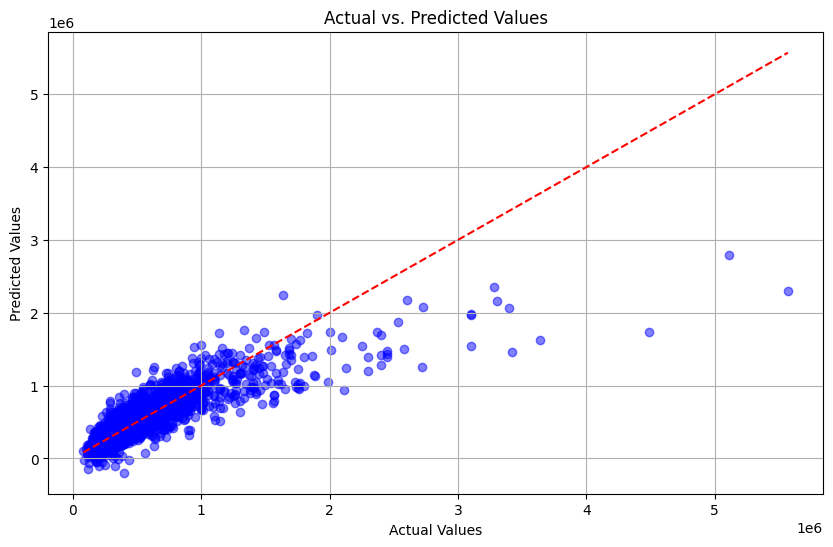

In [ ]:
#visualization between actual vs predicted values
#scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5,color = "blue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.show()


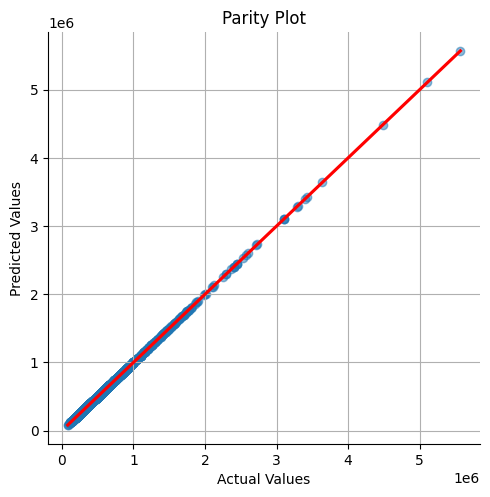

In [ ]:
#now we will try parity plot
import seaborn as sns
import matplotlib.pyplot
parity_plot_data = pd.DataFrame({'Actual': y_test, 'Predicted': y, 'Residuals': y_test - y_pred})
sns.lmplot(x='Actual', y='Predicted', data=parity_plot_data , scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Parity Plot')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

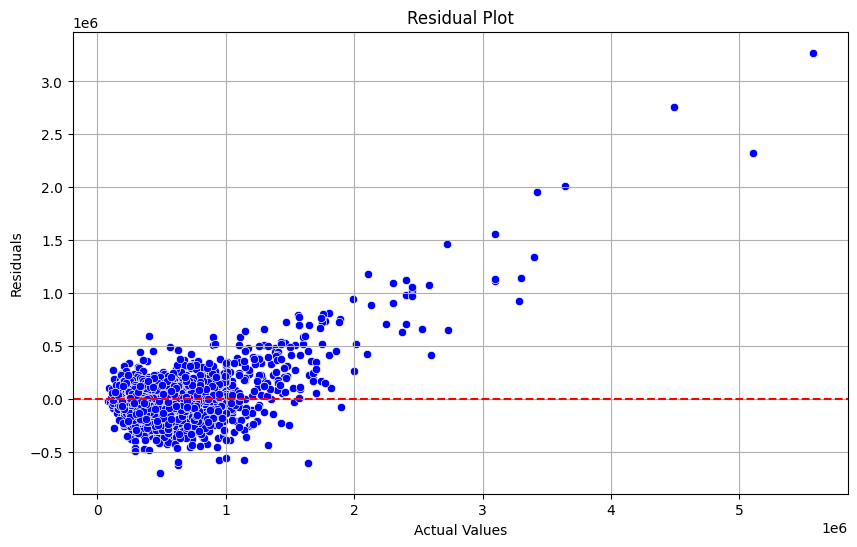

In [ ]:
#now let us plot residual plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()


✅ Should You Change Anything Now?
🔹 If your goal is a clean academic project →

✅ STOP HERE. Your work is already complete and correct.

🔹 If your goal is slightly better performance (optional only):

You can try log-transforming Price:

In [ ]:
#to decrease heteroscedicity
#let y be log(y_train) instead of log(y)
y_train_log = np.log(y_train)
#train ridge on log y_train
ridge_model_log = Ridge(alpha=1.0, random_state=42)
ridge_model_log.fit(X_train, y_train_log)
#apply and convert back
y_pred_log = ridge_model_log.predict(X_test)
y_pred = np.exp(y_pred_log)

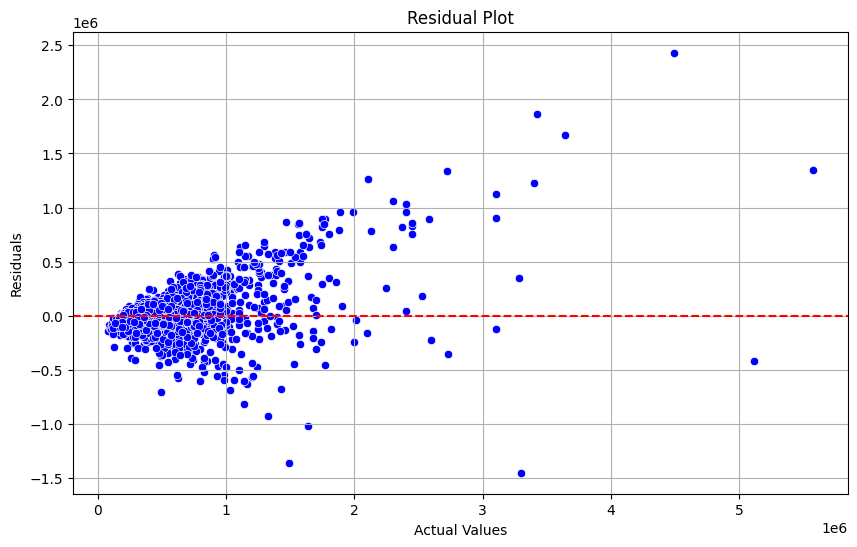

In [ ]:
#visualize the new y_pred with residual plot
y_test_original = y_test.values
residuals = y_test_original - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

In [ ]:
#check predicted vs actual values of y
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5,color = "blue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
